# 1. Load the libraries

In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_colwidth',None)   #this displays the dataframe in full width
import collections
from collections import Counter

# 2. Load the dataset:

In [2]:
df= pd.read_table('braj_dataset.txt',sep='/n',header=None)

C:\ProgramData\Anaconda3\lib\site-packages\pandas\util\_decorators.py:311: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  return func(*args, **kwargs)


In [3]:
df

,0
0,करबा चौथ अरु अघोई आठैं कूँ परकोटा चौक में विविध देवी - देवतान के चित्र चावल पीस कैं काढ़े जाबैं ।
1,बाखरऊ ऐसी लम्बी - चौरी कै एक - एक बाखर छे: - छे: सात - सात गृहस्थी आराम ते रह्यौ करै हे ।
2,ठाट - बाट ते ब्याह है गयौ ।
3,"हम भारतवासीन में इतिहास , विवरण , संस्मरण अरु आत्मचरित के ताँई आरम्भ सौं ही अनूठी अनास्था रही है ।"
4,कोऊ उदाहरन दैकैं समझाऔ ।
...,...
2303,किसान नैं हू लच्छमी कूँ पूरौ - पूरौ भरोसो दै दियौ ।
2304,"कबऊ फुरसत के समय लोहे के वक्सा कूँ खौलिकै देखूँ तौ बामें अनेकन फटे पुराने कपड़ा जैसै सूट , बुसर्ट , टाई कमीज आदि मिलै जिन्नै भूल गयी हूं ।"
2305,राजा मदन सैन नैं राज सिंहासन कौ भार तहाँ रह रहे पांचों पूतन कूं सौपिं कासी के धर्माधिकारी बौद्ध भिक्षु कौ सिस्य बनिकें बैराग्य लै लियौ ।
2306,सालबेग ( सोलहवीं सदी ) संतकवि हे इनके पिता लालबेग मुसलमान और माता अपहृता ब्राह्मण कन्या ही ।


In [4]:
df=df.rename(columns={0:'text'})

In [5]:
df

,text
0,करबा चौथ अरु अघोई आठैं कूँ परकोटा चौक में विविध देवी - देवतान के चित्र चावल पीस कैं काढ़े जाबैं ।
1,बाखरऊ ऐसी लम्बी - चौरी कै एक - एक बाखर छे: - छे: सात - सात गृहस्थी आराम ते रह्यौ करै हे ।
2,ठाट - बाट ते ब्याह है गयौ ।
3,"हम भारतवासीन में इतिहास , विवरण , संस्मरण अरु आत्मचरित के ताँई आरम्भ सौं ही अनूठी अनास्था रही है ।"
4,कोऊ उदाहरन दैकैं समझाऔ ।
...,...
2303,किसान नैं हू लच्छमी कूँ पूरौ - पूरौ भरोसो दै दियौ ।
2304,"कबऊ फुरसत के समय लोहे के वक्सा कूँ खौलिकै देखूँ तौ बामें अनेकन फटे पुराने कपड़ा जैसै सूट , बुसर्ट , टाई कमीज आदि मिलै जिन्नै भूल गयी हूं ।"
2305,राजा मदन सैन नैं राज सिंहासन कौ भार तहाँ रह रहे पांचों पूतन कूं सौपिं कासी के धर्माधिकारी बौद्ध भिक्षु कौ सिस्य बनिकें बैराग्य लै लियौ ।
2306,सालबेग ( सोलहवीं सदी ) संतकवि हे इनके पिता लालबेग मुसलमान और माता अपहृता ब्राह्मण कन्या ही ।


In [6]:
def count_length():
    df['word_count'] = df['text'].apply(lambda x: len(str(x).split(" ")))

In [7]:
count_length()

In [8]:
df

,text,word_count
0,करबा चौथ अरु अघोई आठैं कूँ परकोटा चौक में विविध देवी - देवतान के चित्र चावल पीस कैं काढ़े जाबैं ।,21
1,बाखरऊ ऐसी लम्बी - चौरी कै एक - एक बाखर छे: - छे: सात - सात गृहस्थी आराम ते रह्यौ करै हे ।,23
2,ठाट - बाट ते ब्याह है गयौ ।,8
3,"हम भारतवासीन में इतिहास , विवरण , संस्मरण अरु आत्मचरित के ताँई आरम्भ सौं ही अनूठी अनास्था रही है ।",20
4,कोऊ उदाहरन दैकैं समझाऔ ।,5
...,...,...
2303,किसान नैं हू लच्छमी कूँ पूरौ - पूरौ भरोसो दै दियौ ।,12
2304,"कबऊ फुरसत के समय लोहे के वक्सा कूँ खौलिकै देखूँ तौ बामें अनेकन फटे पुराने कपड़ा जैसै सूट , बुसर्ट , टाई कमीज आदि मिलै जिन्नै भूल गयी हूं ।",30
2305,राजा मदन सैन नैं राज सिंहासन कौ भार तहाँ रह रहे पांचों पूतन कूं सौपिं कासी के धर्माधिकारी बौद्ध भिक्षु कौ सिस्य बनिकें बैराग्य लै लियौ ।,27
2306,सालबेग ( सोलहवीं सदी ) संतकवि हे इनके पिता लालबेग मुसलमान और माता अपहृता ब्राह्मण कन्या ही ।,18


# Remove All Emojis from Text

In [9]:
import re
emoji_pattern = re.compile("["                 
        u"U0001F600-U0001F64F"  # emoticons
        u"U0001F300-U0001F5FF"  # symbols & pictographs
        u"U0001F680-U0001F6FF"  # transport & map symbols
        u"U0001F1E0-U0001F1FF"  # flags (iOS)
        u"U00002500-U00002BEF"  # chinese char
        u"U00002702-U000027B0"
        u"U00002702-U000027B0"
        u"U000024C2-U0001F251"
        u"U0001f926-U0001f937"
        u"U00010000-U0010ffff"
        u"u2640-u2642" 
        u"u2600-u2B55"
        u"u200d"
        u"u23cf"
        u"u23e9"
        u"u231a"
        u"ufe0f"  # dingbats
        u"u3030"
                           "]+", flags=re.UNICODE)

In [10]:
for i in range(len(df)):
    df['text'][i] = emoji_pattern.sub(r'', df['text'][i])
count_length()

C:\Users\RAHUL~1.PAT\AppData\Local\Temp/ipykernel_17868/1993829034.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'][i] = emoji_pattern.sub(r'', df['text'][i])


In [11]:
df

,text,word_count
0,करबा चौथ अरु अघोई आठैं कूँ परकोटा चौक में विविध देवी - देवतान के चित्र चावल पीस कैं काढ़े जाबैं ।,21
1,बाखरऊ ऐसी लम्बी - चौरी कै एक - एक बाखर छे - छे सात - सात गृहस्थी आराम ते रह्यौ करै हे ।,23
2,ठाट - बाट ते ब्याह है गयौ ।,8
3,"हम भारतवासीन में इतिहास , विवरण , संस्मरण अरु आत्मचरित के ताँई आरम्भ सौं ही अनूठी अनास्था रही है ।",20
4,कोऊ उदाहरन दैकैं समझाऔ ।,5
...,...,...
2303,किसान नैं हू लच्छमी कूँ पूरौ - पूरौ भरोसो दै दियौ ।,12
2304,"कबऊ फुरसत के समय लोहे के वक्सा कूँ खौलिकै देखूँ तौ बामें अनेकन फटे पुराने कपड़ा जैसै सूट , बुसर्ट , टाई कमीज आदि मिलै जिन्नै भूल गयी हूं ।",30
2305,राजा मदन सैन नैं राज सिंहासन कौ भार तहाँ रह रहे पांचों पूतन कूं सौपिं कासी के धर्माधिकारी बौद्ध भिक्षु कौ सिस्य बनिकें बैराग्य लै लियौ ।,27
2306,सालबेग ( सोलहवीं सदी ) संतकवि हे इनके पिता लालबेग मुसलमान और माता अपहृता ब्राह्मण कन्या ही ।,18


# remove other unnecessary kinds of stuff like the website URLs or email ids using the code below:

In [12]:
def processText(text):
    text = text.lower()
    text = re.sub('((www.[^s]+)|(https?://[^s]+))','',text)
    text = re.sub('@[^s]+','',text)
    text = re.sub('[s]+', ' ', text)
    text = re.sub(r'#([^s]+)', r'1', text)
    text = re.sub(r'''[-!:.?'"\/]''', r'', text)
    text = text.strip('"')
    return text
for i in range(len(df)):
    df['text'][i] = processText(df['text'][i])

C:\Users\RAHUL~1.PAT\AppData\Local\Temp/ipykernel_17868/3124131011.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'][i] = processText(df['text'][i])


# Generating Tokens for Hindi Text Analysis

In [13]:
from indicnlp.tokenize import indic_tokenize
def tokenization(indic_string):
    tokens = []
    for t in indic_tokenize.trivial_tokenize(indic_string):
        tokens.append(t)
    return tokens
df['text'] = df['text'].apply(lambda x: tokenization(x))

In [14]:

df

,text,word_count
0,"[करबा, चौथ, अरु, अघोई, आठैं, कूँ, परकोटा, चौक, में, विविध, देवी, देवतान, के, चित्र, चावल, पीस, कैं, काढ़े, जाबैं, ।]",21
1,"[बाखरऊ, ऐसी, लम्बी, चौरी, कै, एक, एक, बाखर, छे, छे, सात, सात, गृहस्थी, आराम, ते, रह्यौ, करै, हे, ।]",23
2,"[ठाट, बाट, ते, ब्याह, है, गयौ, ।]",8
3,"[हम, भारतवासीन, में, इतिहास, ,, विवरण, ,, संस्मरण, अरु, आत्मचरित, के, ताँई, आरम्भ, सौं, ही, अनूठी, अनास्था, रही, है, ।]",20
4,"[कोऊ, उदाहरन, दैकैं, समझाऔ, ।]",5
...,...,...
2303,"[किसान, नैं, हू, लच्छमी, कूँ, पूरौ, पूरौ, भरोसो, दै, दियौ, ।]",12
2304,"[कबऊ, फुरसत, के, समय, लोहे, के, वक्सा, कूँ, खौलिकै, देखूँ, तौ, बामें, अनेकन, फटे, पुराने, कपड़ा, जैसै, सूट, ,, बुसर्ट, ,, टाई, कमीज, आदि, मिलै, जिन्नै, भूल, गयी, हूं, ।]",30
2305,"[राजा, मदन, सैन, नैं, राज, सिंहासन, कौ, भार, तहाँ, रह, रहे, पांचों, पूतन, कूं, सौपिं, कासी, के, धर्माधिकारी, बौद्ध, भिक्षु, कौ, सिस्य, बनिकें, बैराग्य, लै, लियौ, ।]",27
2306,"[सालबेग, (, सोलहवीं, सदी, ), संतकवि, हे, इनके, पिता, लालबेग, मुसलमान, और, माता, अपहृता, ब्राह्मण, कन्या, ही, ।]",18


# Remove ‘\n’ from each token

In [15]:
for i in range(len(df)):
    df['text'][i] = [s.replace("\n", "") for s in df['text'][i]]

C:\Users\RAHUL~1.PAT\AppData\Local\Temp/ipykernel_17868/547715004.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'][i] = [s.replace("\n", "") for s in df['text'][i]]


In [16]:
df

,text,word_count
0,"[करबा, चौथ, अरु, अघोई, आठैं, कूँ, परकोटा, चौक, में, विविध, देवी, देवतान, के, चित्र, चावल, पीस, कैं, काढ़े, जाबैं, ।]",21
1,"[बाखरऊ, ऐसी, लम्बी, चौरी, कै, एक, एक, बाखर, छे, छे, सात, सात, गृहस्थी, आराम, ते, रह्यौ, करै, हे, ।]",23
2,"[ठाट, बाट, ते, ब्याह, है, गयौ, ।]",8
3,"[हम, भारतवासीन, में, इतिहास, ,, विवरण, ,, संस्मरण, अरु, आत्मचरित, के, ताँई, आरम्भ, सौं, ही, अनूठी, अनास्था, रही, है, ।]",20
4,"[कोऊ, उदाहरन, दैकैं, समझाऔ, ।]",5
...,...,...
2303,"[किसान, नैं, हू, लच्छमी, कूँ, पूरौ, पूरौ, भरोसो, दै, दियौ, ।]",12
2304,"[कबऊ, फुरसत, के, समय, लोहे, के, वक्सा, कूँ, खौलिकै, देखूँ, तौ, बामें, अनेकन, फटे, पुराने, कपड़ा, जैसै, सूट, ,, बुसर्ट, ,, टाई, कमीज, आदि, मिलै, जिन्नै, भूल, गयी, हूं, ।]",30
2305,"[राजा, मदन, सैन, नैं, राज, सिंहासन, कौ, भार, तहाँ, रह, रहे, पांचों, पूतन, कूं, सौपिं, कासी, के, धर्माधिकारी, बौद्ध, भिक्षु, कौ, सिस्य, बनिकें, बैराग्य, लै, लियौ, ।]",27
2306,"[सालबेग, (, सोलहवीं, सदी, ), संतकवि, हे, इनके, पिता, लालबेग, मुसलमान, और, माता, अपहृता, ब्राह्मण, कन्या, ही, ।]",18


# Remove Stopwords and Punctuations and most frequent unnecessary words

In [17]:
import string

In [18]:
pun = list(string.punctuation)
pun

['!',
 '"',
 '#',
 '$',
 '%',
 '&',
 "'",
 '(',
 ')',
 '*',
 '+',
 ',',
 '-',
 '.',
 '/',
 ':',
 ';',
 '<',
 '=',
 '>',
 '?',
 '@',
 '[',
 '\\',
 ']',
 '^',
 '_',
 '`',
 '{',
 '|',
 '}',
 '~']

In [19]:
stop_word = pd.read_table('stop_hindi.txt',sep='/n',header=None,names=['word'])
freq_word = pd.read_table('frequent_word_hindi.txt',sep='/n',header=None,names=['word'])

C:\ProgramData\Anaconda3\lib\site-packages\pandas\util\_decorators.py:311: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  return func(*args, **kwargs)


In [20]:
stop_word = freq_word['word'].tolist()+stop_word['word'].tolist() + pun

In [21]:
stop_word.append('।')

In [22]:
corpus_list =[]
for i in range(len(df)):
    corpus_list +=df['text'][i]
counter=collections.Counter(corpus_list)
print(counter)

Counter({'।': 2177, ',': 1209, 'के': 979, 'है': 778, 'में': 770, 'की': 737, 'कौ': 572, 'कूँ': 360, 'तौ': 337, 'और': 321, 'नैं': 290, 'सौं': 283, 'अरु': 275, 'पै': 266, 'ते': 262, 'एक': 248, 'ही': 242, 'कै': 200, 'हैं': 189, 'गयौ': 179, 'माँहि': 149, 'अपने': 136, 'या': 129, 'लोक': 125, 'जी': 122, 'मैं': 120, 'नाँय': 109, 'ब्रजभाषा': 104, 'भयौ': 98, 'जा': 96, 'हू': 94, 'बात': 93, 'गई': 90, 'जि': 88, 'दियौ': 87, 'घर': 86, 'अपनी': 85, 'जो': 82, 'कैं': 81, 'हे': 81, 'श्री': 81, 'संग': 81, 'साहित्य': 79, 'रूप': 77, 'जाय': 77, 'होय': 76, 'कवि': 76, 'भैया': 75, 'दई': 73, 'करै': 71, 'मन': 71, 'काम': 71, 'गये': 67, 'करौ': 66, 'पर': 65, 'वे': 65, 'हौ': 65, 'हम': 64, 'मेरे': 63, 'कथा': 63, 'तो': 63, 'रह्यौ': 62, 'राजा': 62, 'किसान': 61, 'भई': 59, 'रहे': 59, 'ई': 59, 'अब': 58, 'बिनके': 58, 'डॉ': 56, 'बू': 56, 'ब्रज': 55, 'जब': 54, 'कही': 54, 'कोऊ': 53, 'संस्कृति': 53, 'कर': 53, 'रही': 52, 'जीवन': 52, 'न': 52, 'फिर': 52, 'का': 51, 'करी': 50, 'दिना': 50, '(': 48, ')': 48, 'भये': 48, 'अरू': 48, 'पास':

In [23]:
for i in range(len(df)):
    df['text'][i]=[ele for ele in df['text'][i] if ele not in (stop_word)]
count_length()

C:\Users\RAHUL~1.PAT\AppData\Local\Temp/ipykernel_17868/3416307382.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'][i]=[ele for ele in df['text'][i] if ele not in (stop_word)]


In [24]:
df

,text,word_count
0,"[करबा, चौथ, अघोई, आठैं, परकोटा, चौक, विविध, देवी, देवतान, चित्र, चावल, पीस, काढ़े, जाबैं]",14
1,"[बाखरऊ, ऐसी, लम्बी, चौरी, बाखर, छे, छे, सात, सात, गृहस्थी, आराम, रह्यौ]",12
2,"[ठाट, बाट, ब्याह]",3
3,"[भारतवासीन, इतिहास, विवरण, संस्मरण, आत्मचरित, ताँई, आरम्भ, अनूठी, अनास्था]",9
4,"[उदाहरन, दैकैं, समझाऔ]",3
...,...,...
2303,"[किसान, लच्छमी, पूरौ, पूरौ, भरोसो]",5
2304,"[कबऊ, फुरसत, समय, लोहे, वक्सा, खौलिकै, देखूँ, बामें, अनेकन, फटे, पुराने, कपड़ा, जैसै, सूट, बुसर्ट, टाई, कमीज, मिलै, जिन्नै, भूल, गयी]",21
2305,"[राजा, मदन, सैन, राज, सिंहासन, भार, तहाँ, रह, पांचों, पूतन, सौपिं, कासी, धर्माधिकारी, बौद्ध, भिक्षु, सिस्य, बनिकें, बैराग्य, लियौ]",19
2306,"[सालबेग, सोलहवीं, सदी, संतकवि, इनके, पिता, लालबेग, मुसलमान, माता, अपहृता, ब्राह्मण, कन्या]",12


# Word Cloud for Hindi Text Analysis

download the hindi font from following url to create wordcloud https://www.lipikaar.com/support/download-unicode-fonts-for-hindi-marathi-sanskrit-nepali

1. Download the above-mentioned fonts.



2. Extract it and copy the “gargi.ttf” in the project directory.


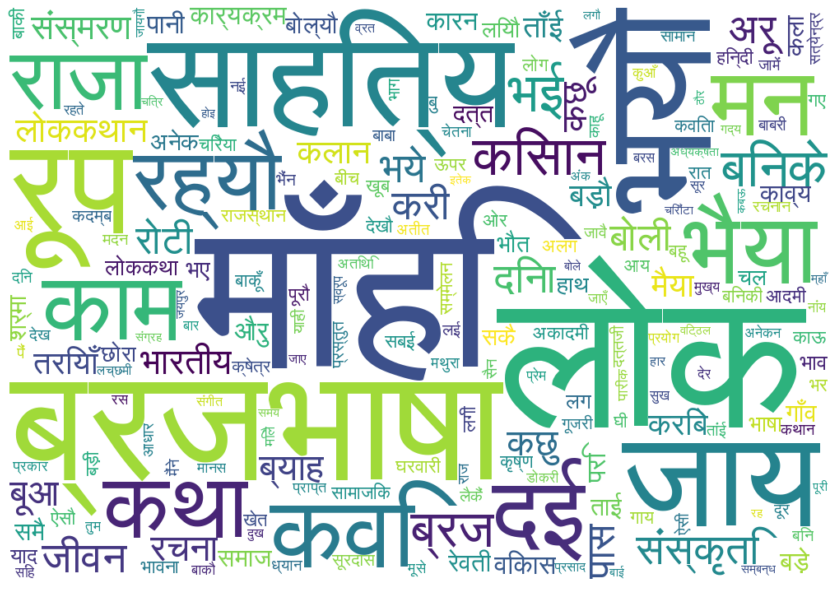

In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
font = "Devanagari/gargi.ttf"
df_list = []
for i in range(len(df)):
    df_list +=df['text'][i]
dictionary=Counter(df_list)
wordcloud = WordCloud(width = 1000, height = 700,
                background_color ='white',
                min_font_size = 10,font_path=font).generate_from_frequencies(dictionary)
# plot the WordCloud image                      
plt.figure(figsize = (18, 8), facecolor = None)
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

In [26]:
least_common= [word for word, word_count in Counter(corpus_list).most_common()[:-50:-1]]

In [27]:
least_common

['अपहृता',
 'लालबेग',
 'संतकवि',
 'सोलहवीं',
 'सालबेग',
 'बनिकें',
 'सौपिं',
 'पूतन',
 'पांचों',
 'सिंहासन',
 'जिन्नै',
 'कमीज',
 'बुसर्ट',
 'खौलिकै',
 'वक्सा',
 'लोहे',
 'भरोसो',
 'सर्वेसर्वा',
 'काटी',
 'छीजत',
 'पिसाइ',
 'लाय्कौ',
 'सुनभाई',
 'खेलतौ',
 'हँसतौ',
 'मूसय',
 'अवतौ',
 'ब्रजलीलान',
 'नाना',
 'लैनौ',
 'टक्कर',
 'चाहैं',
 'ठहरिबौ',
 'धरमसाला',
 'ब्यौपार',
 'परलै',
 'शाश्वत',
 'सुरसाधनात्मक',
 'लोकगायन',
 'सक्रिय',
 'जीवाणु',
 'निगाह',
 'देशन',
 'अरब',
 'यहीं',
 'लेवै',
 'कृष्णपरक',
 'पदन',
 'दिग्दर्शन']

In [28]:
from nltk import ngrams
def _generate_grams(column):
    max_grams = int(column.str.split("\\s+").str.len().max())
#     print(max_grams)
    grams_dict = {}
    for i in range(1, max_grams+1):
        grams = []
        for j in range(len(column)):
            g = []
            n_grams = ngrams(column[j].strip().split(), i)
            for k in n_grams:
                    g.append(" ".join(k))
            grams.extend(g)
        freq = Counter(grams)
        s = dict(freq.most_common())
        final_grams = {}
        for key, value in s.items():
            if value >= 1: #minimun records 10
                final_grams[key] = value
            else:
                break
        grams_dict[i] = final_grams
    return grams_dict

In [31]:
def generate_N_grams(text,ngram=1):
    temp=zip(*[text[i:] for i in range(0,ngram)])
    ans=[' '.join(ngram) for ngram in temp]
    return ans

In [33]:
generate_N_grams(df['text'][0],2)

['करबा चौथ',
 'चौथ अघोई',
 'अघोई आठैं',
 'आठैं परकोटा',
 'परकोटा चौक',
 'चौक विविध',
 'विविध देवी',
 'देवी देवतान',
 'देवतान चित्र',
 'चित्र चावल',
 'चावल पीस',
 'पीस काढ़े',
 'काढ़े जाबैं']